# View Factor Calculation for Cone Heater to Target Surface

This code calculates the view factors between a cone calorimeter heater and a target surface, mapping the view factor distribution based on differential elements across the surface.

## Parameters:
- **d**: Vertical distance between the cone heater base and the target specimen (in mm).
- **p**: Diameter of the target/differential element (in mm).
- **num_points**: Number of points used to discretize the (h, k) grid on the target surface.
- **h_values**: List of values representing the location of the differential element in the x-direction over the specimen surface.
- **k_values**: List of values representing the location of the differential element in the y-direction over the specimen surface.
- **theta_values**: List of angles in radians at which view factors are to be calculated, *representing the inclination angle of the target surface relative to the surface of the specimen*.
- **theta_values_degree**: List of angles in degrees corresponding to the inclination angles used for the target surface.

## How It Works:
1. **Meshgrid Creation**: The code generates a 3D meshgrid based on the given **h_values**, **k_values**, and **theta_values**, where **h** and **k** correspond to the x and y coordinates of the differential element on the specimen surface, and **theta** corresponds to the inclination angle.
   
2. **View Factor Calculation**: Using the generated grid, the code iterates through each combination of (h, k, theta) and computes the view factor (VF) using the provided view factor function (either **VF_X_AXIS** or **VF_Y_AXIS**).

3. **Progress Reporting**: During the iteration, the code reports the progress, including the number of calculated points and the elapsed time.

4. **Data Storage**: The results are stored in a DataFrame, with columns for the h, k, and theta values, as well as the computed view factor (VF). The DataFrame is then saved as a CSV file.

5. **Plotting**: After saving the results, the code plots the view factor distribution for a specified angle (e.g., 5 degrees).

## Output:
- The results are saved as CSV files for both the X and Y axis view factor calculations, with filenames indicating the calculation parameters.
- View factor distributions are plotted for specific target angles.

In [18]:
import numpy as np
import pandas as pd
import time
from scipy.integrate import dblquad, IntegrationWarning
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.interpolate import griddata
import warnings
import seaborn as sns
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [26]:
# Set plotting style and LaTeX options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  
})
sns.set_context("paper", font_scale=1.5)

In [27]:
def VF_X_AXIS(args):
    """Compute view factor for given parameters."""
    d, p, h, k, theta = args

    # Parameters in mm
    R1, R2, H = 40, 40, 65  
    
    I1 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)*np.cos(theta)+h-(-R1-R2+(R2*v)/(19*np.pi))*np.cos(v))**2+
                                                  (0.5*p*np.sin(u)+k-(-R1-R2+(R2*v)/(19*np.pi))*np.sin(v))**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.cos(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(H*v/(19*np.pi)))**2
                                                 )*0.5*p*((-R1-R2+(R2*v/(19*np.pi)))*(np.sin(v)*np.cos(theta)*np.sin(u)+np.cos(v)*np.cos(u))+(R2/(19*np.pi))*(np.cos(u)*np.sin(v)-np.cos(v)*np.cos(theta)*np.sin(u))-np.sin(theta)*np.sin(u)*H/(19*np.pi))
    I2 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)*np.cos(theta)+h-(-R1-R2+(R2*v)/(19*np.pi))*np.cos(v))**2+
                                                  (0.5*p*np.sin(u)+k-(-R1-R2+(R2*v)/(19*np.pi))*np.sin(v))**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.cos(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(H*v/(19*np.pi)))**2
                                                 )*0.5*p*((-R1-R2+(R2*v/(19*np.pi)))*(np.sin(v)*np.cos(theta)*np.sin(u)+np.cos(v)*np.cos(u))+(R2/(19*np.pi))*(np.cos(u)*np.sin(v)-np.cos(v)*np.cos(theta)*np.sin(u))-np.sin(theta)*np.sin(u)*H/(19*np.pi))
    I3 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)*np.cos(theta)+h-(np.sqrt(R2**2 + H**2)/19)*np.cos(v)+R1+18*R2/19)**2+
                                                  (0.5*p*np.sin(u)+k)**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.cos(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(np.sqrt(R2**2 + H**2)/19)*np.sin(v)-H/19)**2
                                                 )*(p/38)*np.sqrt(R2**2 + H**2)*np.sin(u)*np.sin(v-theta)
    I4 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)*np.cos(theta)+h-(np.sqrt(R2**2 + H**2)/19)*np.cos(v)-R1-R2/19)**2+
                                                  (0.5*p*np.sin(u)+k)**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.cos(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(np.sqrt(R2**2 + H**2)/19)*np.sin(v)-18*H/19)**2
                                                 )*(p/38)*np.sqrt(R2**2 + H**2)*np.sin(u)*np.sin(v-theta)

    VF=(dblquad(I1,17*np.pi,0,0,2*np.pi)[0] + dblquad(I2,2*np.pi,19*np.pi,0,2*np.pi)[0] + dblquad(I3,np.arctan(H/R2)-np.pi,np.arctan(H/R2),0,2*np.pi)[0] + dblquad(I4,np.pi-np.arctan(H/R2),2*np.pi-np.arctan(H/R2),0,2*np.pi)[0])

    return h, k, theta, VF


def VF_Y_AXIS(args):
    """Compute view factor for given parameters."""
    d, p, h, k, theta = args

    # Parameters in mm
    R1, R2, H = 40, 40, 65  
    
    I1 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)+h-(-R1-R2+(R2*v)/(19*np.pi))*np.cos(v))**2+
                                                  (0.5*p*np.cos(theta)*np.sin(u)+k-(-R1-R2+(R2*v)/(19*np.pi))*np.sin(v))**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.sin(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(H*v/(19*np.pi)))**2
                                                 )*0.5*p*((-R1-R2+(R2*v/(19*np.pi)))*(np.sin(v)*np.sin(u)+np.cos(v)*np.cos(u)*np.cos(theta))+(R2/(19*np.pi))*(np.cos(u)*np.sin(v)*np.cos(theta)-np.cos(v)*np.sin(u))+np.sin(theta)*np.cos(u)*H/(19*np.pi))
    I2 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)+h-(-R1-R2+(R2*v)/(19*np.pi))*np.cos(v))**2+
                                                  (0.5*p*np.cos(theta)*np.sin(u)+k-(-R1-R2+(R2*v)/(19*np.pi))*np.sin(v))**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.sin(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(H*v/(19*np.pi)))**2
                                                 )*0.5*p*((-R1-R2+(R2*v/(19*np.pi)))*(np.sin(v)*np.sin(u)+np.cos(v)*np.cos(u)*np.cos(theta))+(R2/(19*np.pi))*(np.cos(u)*np.sin(v)*np.cos(theta)-np.cos(v)*np.sin(u))+np.sin(theta)*np.cos(u)*H/(19*np.pi))
    I3 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)+h-(np.sqrt(R2**2 + H**2)/19)*np.cos(v)+R1+18*R2/19)**2+
                                                  (0.5*p*np.cos(theta)*np.sin(u)+k)**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.sin(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(np.sqrt(R2**2 + H**2)/19)*np.sin(v)-H/19)**2
                                                 )*(p/38)*np.sqrt(R2**2 + H**2)*(np.sin(u)*np.sin(v)+np.sin(theta)*np.cos(u)*np.cos(v))
    I4 =lambda u,v:( 1/(np.pi*np.pi*p**2))*np.log((0.5*p*np.cos(u)+h-(np.sqrt(R2**2 + H**2)/19)*np.cos(v)-R1-R2/19)**2+
                                                  (0.5*p*np.cos(theta)*np.sin(u)+k)**2+
                                                  (np.tan(theta)*(0.5*p*np.cos(theta)*np.sin(u)+h+0.5*p*np.cos(theta))-d-0.5*p*np.sin(theta)-(np.sqrt(R2**2 + H**2)/19)*np.sin(v)-18*H/19)**2
                                                 )*(p/38)*np.sqrt(R2**2 + H**2)*(np.sin(u)*np.sin(v)+np.sin(theta)*np.cos(u)*np.cos(v))

    VF=(dblquad(I1,17*np.pi,0,0,2*np.pi)[0] + dblquad(I2,2*np.pi,19*np.pi,0,2*np.pi)[0] + dblquad(I3,np.arctan(H/R2)-np.pi,np.arctan(H/R2),0,2*np.pi)[0] + dblquad(I4,np.pi-np.arctan(H/R2),2*np.pi-np.arctan(H/R2),0,2*np.pi)[0])

    return h, k, theta, VF

def plot_view_factor(df, theta_deg):
    """
    Generates a contour plot of view factors for a specific theta_deg.
    
    Parameters:
        df (pd.DataFrame): Dataframe containing 'h', 'k', 'theta_deg', 'theta', and 'VF' columns.
        theta_deg (float): The theta degree value to filter the dataframe before plotting.
        save_plot (bool): If True, prompts the user to enter a filename and saves the plot as a PDF.
    
    Returns:
        None
    """
    # Filter dataframe for the specified theta_deg
    df_filtered = df[df['theta_deg'] == theta_deg]

    if df_filtered.empty:
        print(f"No data available for theta_deg = {theta_deg}")
        return

    # Extract h, k, and VF values
    h = df_filtered['h'].values / np.cos(df_filtered['theta'])
    k = df_filtered['k'].values / np.cos(df_filtered['theta'])
    VF = df_filtered['VF'].values

    # Define grid for interpolation
    h_grid = np.linspace(h.min(), h.max(), 100)
    k_grid = np.linspace(k.min(), k.max(), 100)
    h_grid, k_grid = np.meshgrid(h_grid, k_grid)

    # Interpolate VF values onto the grid
    VF_grid = griddata((h, k), VF, (h_grid, k_grid), method='cubic')

    VF_min = df_filtered['VF'].min()
    VF_max = df_filtered['VF'].max()

    plt.figure(figsize=(5, 4))
    contour = plt.contourf(h_grid, k_grid, VF_grid, levels=40, cmap='inferno', vmin=VF_min, vmax=VF_max)
    colorbar = plt.colorbar(contour, label='View factor ($-$)')
    colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.grid(linestyle=':', color='k', alpha=0.05)

    # Set axis limits
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)

    # Generate intermediate ticks
    x_ticks = np.arange(-50, 51, 25)  
    y_ticks = np.arange(-50, 51, 25)  

    # Set ticks explicitly
    plt.gca().set_xticks(x_ticks)
    plt.gca().set_yticks(y_ticks)

    plt.tick_params(axis='both', which='both', direction='in', right=True, top=True)
    plt.grid(linestyle=':', color='k', alpha=0.05)

    plt.xlabel('$h$ (mm)')
    plt.ylabel('$k$ (mm)')
    plt.title(f'View Factor Contour Plot ($\\theta$ = {theta_deg}°)')

    # Save plot if requested
    save_option = input("Do you want to save the plot? (y/n): ").strip().lower()
    if save_option == "y":
        filename = input("Enter the filename (without extension): ").strip()
        filepath = f"{filename}.pdf"
        plt.savefig(filepath, bbox_inches='tight')
        print(f"Plot saved as {filepath}")

    plt.show()

In [14]:
def compute_VF(h_values, k_values, theta_values, theta_values_degree, d, p, VF_function):
    start_time = time.time()
    results = []
    
    # Create meshgrid for h, k, and theta values
    H, K, Theta = np.meshgrid(h_values, k_values, theta_values, indexing='ij')
    
    # Flatten the meshgrid for iteration
    for i, (h, k, theta) in enumerate(zip(H.ravel(), K.ravel(), Theta.ravel())):
        original_theta = theta_values_degree[i % len(theta_values_degree)]  # Corresponding degree value

        # Compute VF using the provided function
        args = (d, p, h, k, theta)
        _, _, _, VF = VF_function(args)  # Unpack only the VF value

        # Append clean data directly
        results.append((h, k, original_theta, theta, VF))

        # Print progress
        if (i + 1) % 50 == 0 or i + 1 == len(H.ravel()):
            elapsed_time = time.time() - start_time
            print(f'Computed {i + 1} points, Elapsed Time: {elapsed_time/60:.2f} min, Theta: {original_theta} deg')
    
    # Return results as a DataFrame
    return pd.DataFrame(results, columns=['h', 'k', 'theta_deg', 'theta', 'VF'])

In [7]:
# Parameters
d = 30                         
p = 10**(-5)                   
num_points = 100
h_values = np.linspace(-52, 52, int(np.sqrt(num_points)))
k_values = np.linspace(-52, 52, int(np.sqrt(num_points)))
theta_values = np.radians([0,5])
theta_values_degree = [0, 5]  

## Compute VF across the $x$ axis

In [8]:
# Compute all view factors
df_X = compute_VF(h_values, k_values, theta_values, theta_values_degree, d, p, VF_X_AXIS)

# Save results to CSV
filename = f'VF_X_AXIS_results_d{d}_TEST.csv'
df_X.to_csv(filename, index=False)
print(f"CSV file saved as '{filename}'")

Computed 50 points, Elapsed Time: 0.54 min, Theta: 5 deg
Computed 100 points, Elapsed Time: 0.97 min, Theta: 5 deg
Computed 150 points, Elapsed Time: 1.41 min, Theta: 5 deg
Computed 200 points, Elapsed Time: 1.96 min, Theta: 5 deg
CSV file saved as 'VF_X_AXIS_results_d30_TEST.csv'


## Compute VF across the $y$ axis

In [15]:
# Compute all view factors
df_Y = compute_VF(h_values, k_values, theta_values, theta_values_degree, d, p, VF_Y_AXIS)

# Save results to CSV
filename = f'VF_Y_AXIS_results_d{d}_TEST.csv'
df_Y.to_csv(filename, index=False)
print(f"CSV file saved as '{filename}'")

Computed 50 points, Elapsed Time: 0.54 min, Theta: 5 deg
Computed 100 points, Elapsed Time: 0.98 min, Theta: 5 deg
Computed 150 points, Elapsed Time: 1.42 min, Theta: 5 deg
Computed 200 points, Elapsed Time: 1.97 min, Theta: 5 deg
CSV file saved as 'VF_Y_AXIS_results_d30_TEST.csv'


# Heatmap of VF

## $x$-axis

Do you want to save the plot? (y/n):  y
Enter the filename (without extension):  X_5deg


Plot saved as X_5deg.pdf


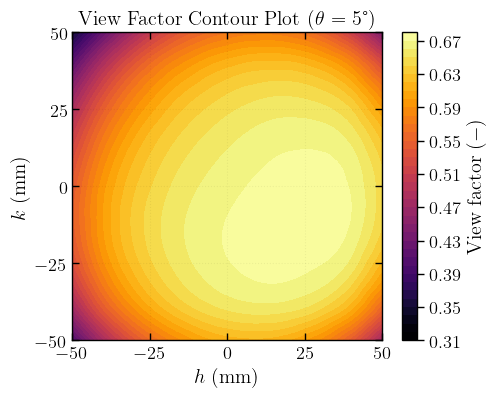

In [29]:
plot_view_factor(df_X, theta_deg=5)

## $y$-axis

Do you want to save the plot? (y/n):  y
Enter the filename (without extension):  Y_5deg


Plot saved as Y_5deg.pdf


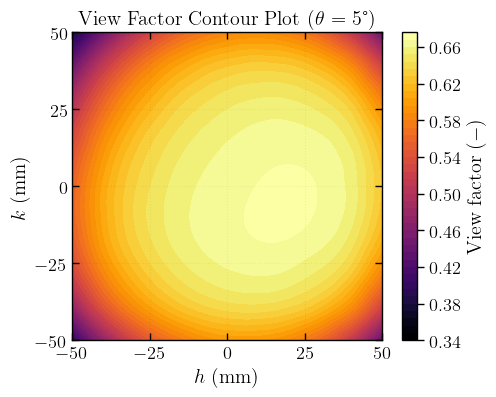

In [30]:
plot_view_factor(df_Y, theta_deg=5)